# 情報数学Ⅲ 第4回

### 🔍 利用方法

- このノートブックは**閲覧専用**です。  
  自分のGoogleドライブにコピーを作成してから編集してください。

  1. メニューの「**ファイル → ドライブにコピーを保存**」を選ぶ  
  2. コピーしたノートブックの**ファイル名（左上の"xxxx"）を学籍番号に変更**してください（提出時の識別のため）

---

### 🔧 提出手順

1. Google Colab の右上にある「**共有**」ボタンをクリック  
2. 「**一般的なアクセス**」の設定を「**リンクを知っている全員**」に変更  
3. アクセス権を「**閲覧者**」に設定（⚠️「編集者」にしないこと！）  
4. 表示されるURLをコピー  
5. WebClassの提出フォームに、その**URLを貼り付けて提出**

---

### 💡 補足・注意点

- **「編集者」ではなく「閲覧者」**に設定してください。  
  → 教員が間違ってファイルを上書きしてしまうのを防ぐためです。
- **提出したリンクを自分でも一度開いてみて、ちゃんと共有されているかを確認**してください。

In [12]:
# 使用するライブラリのインポート
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson # ポアソン分布
from scipy.stats import binom # 二項分布
from scipy.stats import norm # 正規分布
from scipy.stats import skew, kurtosis # 歪度、尖度
import pandas as pd

# 日本語表示: Colab環境用
!pip install japanize_matplotlib
import japanize_matplotlib

# 日本語表示: Mac環境用
# 日本語フォントを指定（ヒラギノ角ゴがmacOSに標準搭載）
#plt.rcParams['font.family'] = 'Hiragino Sans'


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 36.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=806c327c66e0a2be8e60fb2d0fb69f2bf7786da42d89bf01acab6826b6562b24
  Stored in directory: /root/.cache/pip/wheels/da/a1/71/b8faeb93276fed10edffcca20746f1ef6f8d9e071eee8425fc
Successfully built japanize_matplotlib


## ポアソン分布のグラフを書いてみよう

In [13]:
# xの値の範囲
x = np.arange(0, 21)
# x = np.arange(start=0, stop=21, step=1) # 参考：丁寧に書くとこうなる．0から20までの整数を生成．stopの22は含まれないので注意

# λ=1のポアソン分布
pmf_1 = poisson.pmf(x, 1)

# λ=5のポアソン分布
pmf_5 = poisson.pmf(x, 5)

# λ=10のポアソン分布
pmf_10 = poisson.pmf(x, 10)


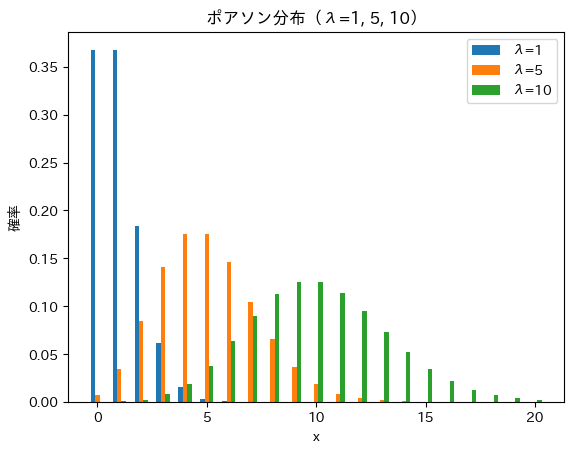

In [14]:
# 参考：グラフのサイズ→指定するとサイズが少し大きくなって見やすい
#plt.figure(figsize=(10, 6))

# 棒グラフを描画（少し横にずらして重ならないようにする）
plt.bar(x - 0.2, pmf_1, width=0.2, label='λ=1')
plt.bar(x,         pmf_5, width=0.2, label='λ=5')
plt.bar(x + 0.2, pmf_10, width=0.2, label='λ=10')

# グラフの設定
plt.title('ポアソン分布（λ=1, 5, 10）') # グラフのタイトル
plt.xlabel('x') # x軸のラベル
plt.ylabel('確率')  # y軸のラベル
plt.legend() # 凡例
#plt.xticks(x)
#plt.grid(True)

# グラフを表示
plt.show()

## 例題
日本では2006年4月-2011年3月の5年間にマグニチュード7以上の大きな地震は7回起こっている．以下の問いに答えよ

1. 上記の5年間で地震の起こった実績から，3日間のうちにマグニチュード7以上の地震は，日本で平均何回起こるかを答えよ．1年は365日で計算せよ

In [15]:
# 実績データ
total_days = 5 * 365  # 5年間 = 1825日
total_quakes = 7      # 地震の発生回数

# 1日あたりの平均発生回数
daily_average = total_quakes / total_days

# 3日間あたりの平均（λ）
lambda_3days = daily_average * 3

# 出力
print("3日間あたりの平均回数（λ） =", lambda_3days)

3日間あたりの平均回数（λ） = 0.011506849315068493


2. 3日間のうちにマグニチュード7以上の地震が起こる回数の確率は，まれに起こる事象なのでポアソン分布に従うと予測できる．では，このポアソン分布の平均が1.で求めた値であると仮定したときに，3日間のうちに1回以上マグニチュード7以上の地震が起こる確率はいくつか

In [16]:
# 3日間で1回以上地震が起こる確率（P(X >= 1) = 1 - P(0)）

p_0 = poisson.pmf(0, mu=lambda_3days)
p_1_or_more = 1 - p_0

print("3日間で1回以上起きる確率 =", p_1_or_more)

3日間で1回以上起きる確率 = 0.011440898728023674


##  演習

厚生労働省によれば，日本では年間に20204人の食中毒が発生している（2006-2010年の平均値）．以下の問いに答えよ

(1) 千葉県松戸市（人口484600人）において，1日の食中毒の人数の平均はいくらかを，上記の日本の実績から求めよ．日本の人口は127370000人とする
ヒント：例題より少しだけ複雑である，松戸市と日本全体の人口比の考慮要

In [17]:
# 基本情報
annual_cases_japan = 20204
population_japan = 127370000
population_matsudo = 484600

# 1日あたりの日本全体の平均
daily_average_japan = annual_cases_japan / 365

# 人口比から松戸市の1日あたりの平均発生数を推定
lambda_matsudo = daily_average_japan * (population_matsudo / population_japan)

print("松戸市における1日あたりの平均食中毒人数 =", lambda_matsudo)

松戸市における1日あたりの平均食中毒人数 = 0.21060115874256966


(2) 1日の間に食中毒にかかる人の人数はポアソン分布に従うと仮定し，問1で求めた平均の値を利用して，千葉県松戸市において，1日に食中毒にかかる人が0人である確率を求めよ

In [18]:
# P(X = 0) の計算
p_0 = poisson.pmf(0, mu=lambda_matsudo)

print("1日に松戸市で食中毒が0人である確率 =", p_0)

1日に松戸市で食中毒が0人である確率 = 0.8100971026040504


## 例題

統計学の試験の点数が，平均が60点・標準偏差が10の正規分布に従う場合，以下の問に答えよ

(1) あなたの得点が80点だったとするとき，あなたはクラス全体の上位何%ぐらいの位置にいると考えられるか

In [19]:
# 平均と標準偏差
mu = 60
sigma = 10

# (1) 80点は上位何％か？
your_score = 80
lower_prob = norm.cdf(your_score, loc=mu, scale=sigma)
upper_percent = (1 - lower_prob) * 100

print("(1) あなたは上位", upper_percent, "% にいます")


(1) あなたは上位 2.275013194817921 % にいます


(2) クラスの上位10%に入るためには，あなたは最低何点とる必要があるか．

In [20]:
# 上位10%に入るための得点
threshold_score = norm.ppf(0.90, loc=mu, scale=sigma)

print("(2) 上位10%に入るには", threshold_score, "点以上が必要です")

(2) 上位10%に入るには 72.815515655446 点以上が必要です


## 例題

（第2回の演習でも使用した）次のセルにある20戸の農家データを使って以下の問いに答えよ

問：販売金額の(1)歪度と(2)尖度，耕地面積の(3)歪度と(4)尖度を求めよ


In [21]:
farm_sales_data = [
    {"農家番号": 1, "農産物の販売金額": 400, "総経営耕地面積": 60},
    {"農家番号": 2, "農産物の販売金額": 15, "総経営耕地面積": 30},
    {"農家番号": 3, "農産物の販売金額": 480, "総経営耕地面積": 365},
    {"農家番号": 4, "農産物の販売金額": 993, "総経営耕地面積": 190},
    {"農家番号": 5, "農産物の販売金額": 600, "総経営耕地面積": 136},
    {"農家番号": 6, "農産物の販売金額": 150, "総経営耕地面積": 15},
    {"農家番号": 7, "農産物の販売金額": 115, "総経営耕地面積": 37},
    {"農家番号": 8, "農産物の販売金額": 50, "総経営耕地面積": 100},
    {"農家番号": 9, "農産物の販売金額": 0, "総経営耕地面積": 170},
    {"農家番号": 10, "農産物の販売金額": 130, "総経営耕地面積": 70},
    {"農家番号": 11, "農産物の販売金額": 3000, "総経営耕地面積": 783},
    {"農家番号": 12, "農産物の販売金額": 500, "総経営耕地面積": 560},
    {"農家番号": 13, "農産物の販売金額": 200, "総経営耕地面積": 50},
    {"農家番号": 14, "農産物の販売金額": 55, "総経営耕地面積": 35},
    {"農家番号": 15, "農産物の販売金額": 2200, "総経営耕地面積": 595},
    {"農家番号": 16, "農産物の販売金額": 1, "総経営耕地面積": 200},
    {"農家番号": 17, "農産物の販売金額": 900, "総経営耕地面積": 300},
    {"農家番号": 18, "農産物の販売金額": 1000, "総経営耕地面積": 356},
    {"農家番号": 19, "農産物の販売金額": 450, "総経営耕地面積": 155},
    {"農家番号": 20, "農産物の販売金額": 400, "総経営耕地面積": 250}
]

In [22]:
# データをDataFrameに変換
df = pd.DataFrame(farm_sales_data)

# (1) 販売金額の歪度
sales_skew = skew(df["農産物の販売金額"])

# (2) 販売金額の尖度
sales_kurt = kurtosis(df["農産物の販売金額"])

# (3) 耕地面積の歪度
area_skew = skew(df["総経営耕地面積"])

# (4) 耕地面積の尖度
area_kurt = kurtosis(df["総経営耕地面積"])

# 結果の表示
print("(1) 販売金額の歪度:", sales_skew)
print("(2) 販売金額の尖度:", sales_kurt)
print("(3) 耕地面積の歪度:", area_skew)
print("(4) 耕地面積の尖度:", area_kurt)

(1) 販売金額の歪度: 2.0338820294575446
(2) 販売金額の尖度: 3.5112340125130954
(3) 耕地面積の歪度: 1.241202352698695
(4) 耕地面積の尖度: 0.6665796000428168
